<a href="https://colab.research.google.com/github/Jerrylu99/econ5200-assignments/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample

In [ ]:
np.random.seed(42)
zeros=np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros,tips])

print('n=',len(driver_tips))
print('zeros=',np.sum(driver_tips==0))
print('tips=',np.sum(driver_tips==1))
print("min/max =", driver_tips.min(), driver_tips.max())
print("median =", np.median(driver_tips))

len(driver_tips), driver_tips[:10]



n= 250
zeros= 100
tips= 0
min/max = 0.0 21.6707316979366
median = 0.7553316913699188


(250, array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [ ]:
B=10000
n=len(driver_tips)

boot_medians = np.empty(B)

for b in range(B):
    # sample indices with replacement
    idx = np.random.randint(0, n, size=n)
    sample = driver_tips[idx]
    boot_medians[b] = np.median(sample)

# 95% bootstrap CI
ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])

print("Bootstrap median (original) =", np.median(driver_tips))
print("95% bootstrap CI for median =", (ci_low, ci_high))



Bootstrap median (original) = 0.7553316913699188
95% bootstrap CI for median = (np.float64(0.2817246399726829), np.float64(1.2990257845869702))


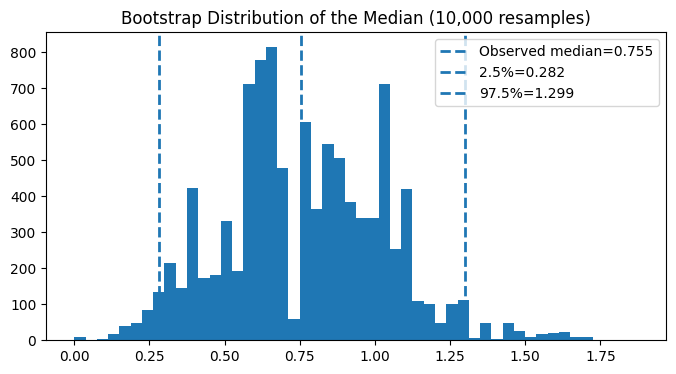

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(boot_medians, bins=50)
plt.axvline(np.median(driver_tips), linestyle='--', linewidth=2, label=f'Observed median={np.median(driver_tips):.3f}')
plt.axvline(ci_low, linestyle='--', linewidth=2, label=f'2.5%={ci_low:.3f}')
plt.axvline(ci_high, linestyle='--', linewidth=2, label=f'97.5%={ci_high:.3f}')
plt.title("Bootstrap Distribution of the Median (10,000 resamples)")
plt.legend()
plt.show()

The tip distribution is zero-inflated and strongly right-skewed. Because of this, normal-based inference may not be appropriate. Bootstrap resampling allows us to estimate the sampling distribution of the median without assuming a specific distribution. The resulting confidence interval is asymmetric, reflecting the skewness of the data.




In [ ]:
np.random.permutation

<bound method RandomState.permutation of RandomState(MT19937) at 0x7893EC132040>

In [ ]:
np.random.seed(42)

control = np.random.normal(loc=35, scale=5, size=500)

treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

obs_diff = np.mean(control) - np.mean(treatment)

print("Control mean:", np.mean(control))
print("Treatment mean:", np.mean(treatment))
print("Observed difference (control - treatment):", obs_diff)

Control mean: 35.03418997294323
Treatment mean: 32.76920784231749
Observed difference (control - treatment): 2.2649821306257394


In [ ]:


combined = np.concatenate([control, treatment])

n_perm = 5000
perm_diffs = np.empty(n_perm)

for i in range(n_perm):

    shuffled = np.random.permutation(combined)

    group1 = shuffled[:500]
    group2 = shuffled[500:]

    perm_diffs[i] = np.mean(group1) - np.mean(group2)


p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print("Observed difference:", obs_diff)
print("Permutation p-value:", p_value)

Observed difference: 2.2649821306257394
Permutation p-value: 0.0004


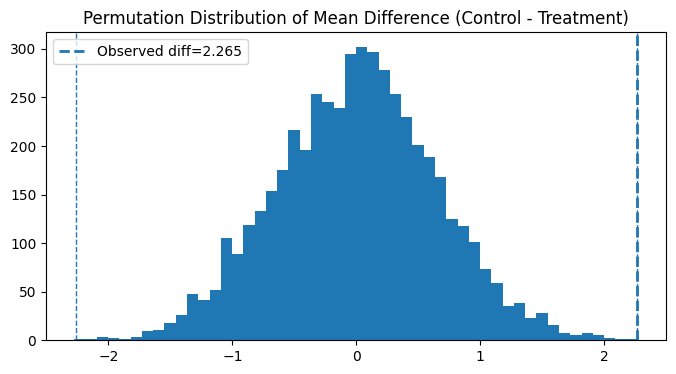

In [ ]:

plt.figure(figsize=(8,4))
plt.hist(perm_diffs, bins=50)
plt.axvline(obs_diff, linestyle='--', linewidth=2, label=f'Observed diff={obs_diff:.3f}')
plt.axvline(-abs(obs_diff), linestyle='--', linewidth=1)
plt.axvline(abs(obs_diff), linestyle='--', linewidth=1)
plt.title("Permutation Distribution of Mean Difference (Control - Treatment)")
plt.legend()
plt.show()


The treatment group follows a log-normal distribution, which is heavily right-skewed and contains extreme values. This violates the equal variance assumption required for a standard t-test.

The permutation test does not rely on distributional assumptions and instead generates the sampling distribution by randomly reshuffling the data. The empirical p-value shows how often a difference as large as the observed one occurs under the null hypothesis of no treatment effect.




In [ ]:
# Step 3.1 load data

import pandas as pd

df = pd.read_csv("swiftcart_loyalty.csv")

df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227


In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv("swiftcart_loyalty.csv")


D_col = "subscriber"
Y_col = "post_spend"
X_cols = ["pre_spend", "account_age", "support_tickets"]

print(df.head())
print(df[X_cols + [D_col, Y_col]].isna().sum())
print(df[D_col].value_counts())

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227
pre_spend          0
account_age        0
support_tickets    0
subscriber         0
post_spend         0
dtype: int64
subscriber
0    4741
1    4200
Name: count, dtype: int64


In [ ]:
D = df[D_col].astype(int)
Y = df[Y_col].astype(float)

naive_sdo = Y[D==1].mean() - Y[D==0].mean()

print("Naive SDO (Subscribers - Non-subscribers) =", naive_sdo)
print("Mean post_spend | D=1 =", Y[D==1].mean())
print("Mean post_spend | D=0 =", Y[D==0].mean())

Naive SDO (Subscribers - Non-subscribers) = 17.57066938452379
Mean post_spend | D=1 = 74.04358604052543
Mean post_spend | D=0 = 56.47291665600164


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

X = df[X_cols].copy()
X = X.fillna(X.median(numeric_only=True))

D = df[D_col].astype(int).values
Y = df[Y_col].astype(float).values

logit = LogisticRegression(max_iter=2000)
logit.fit(X, D)
pscore = logit.predict_proba(X)[:, 1]
df_unmatched = df.copy()
df_unmatched["propensity_score"] = pscore

In [ ]:
treated_idx = np.where(D == 1)[0]
control_idx = np.where(D == 0)[0]

treated_ps = pscore[treated_idx].reshape(-1, 1)
control_ps = pscore[control_idx].reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_ps)

dist, neighbors = nn.kneighbors(treated_ps, n_neighbors=1, return_distance=True)
matched_control_idx = control_idx[neighbors.flatten()]

ATT = np.mean(Y[treated_idx] - Y[matched_control_idx])

print("ATT (PSM matched) =", ATT)
print("Naive SDO =", naive_sdo)
print("Average match distance (propensity score gap) =", dist.mean())

ATT (PSM matched) = 9.913855182824864
Naive SDO = 17.57066938452379
Average match distance (propensity score gap) = 0.00018953341128427202


In [ ]:

df_treated = df_unmatched.iloc[treated_idx].copy()
df_ctrl_matched = df_unmatched.iloc[matched_control_idx].copy()

df_treated["group"] = "treated"
df_ctrl_matched["group"] = "matched_control"

df_matched = pd.concat([df_treated, df_ctrl_matched], axis=0).reset_index(drop=True)

df_unmatched.shape, df_matched.shape


((8941, 6), (8400, 7))

The naive difference in means suggests that subscribers spend about 17.6 more than non-subscribers. However, this estimate is biased because users with higher pre-treatment spending are more likely to subscribe to the loyalty program.

After applying propensity score matching, the ATT provides a more credible estimate of the causal effect. By matching subscribers with non-subscribers who have similar pre-treatment characteristics, the selection bias is reduced. The difference between the naive SDO and the matched ATT indicates that part of the observed spending gap is due to self-selection rather than the true effect of the loyalty program.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

covariates = ["pre_spend", "account_age", "support_tickets"]


def compute_smd(data, treatment_col, var_list, treated_label="treated", control_label="matched_control"):
    smd_values = []

    treated_group = data[data[treatment_col] == treated_label]
    control_group = data[data[treatment_col] == control_label]

    for var in var_list:
        mean_t = treated_group[var].mean()
        mean_c = control_group[var].mean()
        var_t = treated_group[var].var()
        var_c = control_group[var].var()

        pooled_sd = np.sqrt((var_t + var_c) / 2)

        if pooled_sd == 0:
            smd = 0
        else:
            smd = (mean_t - mean_c) / pooled_sd

        smd_values.append(smd)

    return pd.DataFrame({
        "covariate": var_list,
        "smd": smd_values
    })



df_unmatched_plot = df_unmatched.copy()
df_unmatched_plot["group"] = np.where(df_unmatched_plot["subscriber"] == 1, "treated", "matched_control")


before_smd = compute_smd(df_unmatched_plot, "group", covariates,
                         treated_label="treated", control_label="matched_control")
before_smd["sample"] = "Before Matching"

after_smd = compute_smd(df_matched, "group", covariates,
                        treated_label="treated", control_label="matched_control")
after_smd["sample"] = "After Matching"

love_df = pd.concat([before_smd, after_smd], axis=0)

print(love_df)

         covariate       smd           sample
0        pre_spend  0.673959  Before Matching
1      account_age  0.324109  Before Matching
2  support_tickets -0.166146  Before Matching
0        pre_spend  0.013664   After Matching
1      account_age -0.015871   After Matching
2  support_tickets  0.017112   After Matching


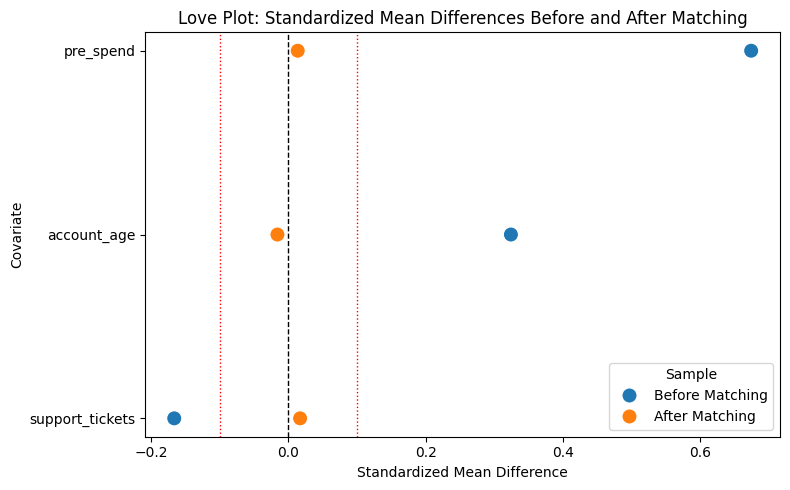

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=love_df,
    x="smd",
    y="covariate",
    hue="sample",
    s=120
)

# reference lines
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.axvline(x=0.1, color="red", linestyle=":", linewidth=1)
plt.axvline(x=-0.1, color="red", linestyle=":", linewidth=1)

plt.title("Love Plot: Standardized Mean Differences Before and After Matching")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariate")
plt.legend(title="Sample")
plt.tight_layout()
plt.show()

The Love Plot shows that the covariates were less balanced before matching, especially for pre-spend. This means the subscriber group and non-subscriber group were different even before treatment, so the naive comparison was biased.

After propensity score matching, the standardized mean differences become much smaller and move closer to zero. This suggests that the matching procedure works well in reducing the imbalance between the two groups. Overall, the plot gives visual evidence that selection bias was reduced after matching.